— Celda 0 — Instalación

In [3]:
import numpy, xgboost, sklearn, shap
!pip install optuna
import optuna

print(f"✅ NumPy:      {numpy.__version__}")
print(f"✅ XGBoost:    {xgboost.__version__}")
print(f"✅ Sklearn:    {sklearn.__version__}")
print(f"✅ SHAP:       {shap.__version__}")
print(f"✅ Optuna:     {optuna.__version__}")

✅ NumPy:      2.0.2
✅ XGBoost:    3.2.0
✅ Sklearn:    1.6.1
✅ SHAP:       0.50.0
✅ Optuna:     4.7.0


— Celda 1 — Imports y configuración

In [4]:
import os, json, shutil, warnings, logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
from optuna.samplers import TPESampler

from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.pipeline import Pipeline
import joblib

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s"
)
logger = logging.getLogger(__name__)

CONFIG = {
    "DATA_DIR":         "/content/data",
    "RAW_FILE":         "/content/data/raw_data.csv",
    "SENTIMENT_FILE":   "/content/data/sentiment_scores.csv",
    "MERGED_FILE":      "/content/data/merged_dataset.csv",
    "MODEL_DIR":        "/content/data/models",
    "DRIVE_DIR":        "/content/drive/MyDrive/ETF_Predictor/data",

    # Walk-forward validation
    "N_SPLITS":         5,       # Folds de TimeSeriesSplit
    "TEST_SIZE":        52,      # ~1 año de semanas para test final
    "GAP":              1,       # 1 semana de gap para evitar data leakage

    # Optuna
    "N_TRIALS":         80,      # Iteraciones de búsqueda de hiperparámetros

    # Targets
    "TARGET_CLASS":     "target_direction",           # Clasificación: sube/baja
    "TARGET_REG":       "target_return_next_week",    # Regresión: cuánto sube/baja
}

os.makedirs(CONFIG["MODEL_DIR"], exist_ok=True)
print("✅ Configuración cargada")

✅ Configuración cargada


— Celda 2 — Restaurar archivos desde Drive y merge

In [5]:
# Celda 2 — Restaurar desde Drive y construir dataset unificado

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

os.makedirs("/content/data", exist_ok=True)

for filename in ["raw_data.csv", "sentiment_scores.csv", "metadata.json"]:
    src  = os.path.join(CONFIG["DRIVE_DIR"], filename)
    dest = os.path.join(CONFIG["DATA_DIR"], filename)
    if os.path.exists(src):
        shutil.copy2(src, dest)
        print(f"✅ Restaurado: {filename}")
    else:
        print(f"⚠️  No encontrado: {filename}")


def merge_datasets(raw_path: str, sentiment_path: str) -> pd.DataFrame:
    """
    Une raw_data.csv y sentiment_scores.csv alineando por semana.
    Aplica forward-fill de máximo 2 semanas para gaps de sentimiento.
    """
    df_raw  = pd.read_csv(raw_path, index_col="date", parse_dates=True)
    df_sent = pd.read_csv(sentiment_path, index_col="date", parse_dates=True)

    logger.info(f"📊 raw_data:         {df_raw.shape}")
    logger.info(f"📊 sentiment_scores: {df_sent.shape}")

    # Alinear índices temporales (left join para preservar todas las semanas)
    df = df_raw.join(df_sent, how="left", rsuffix="_sent")

    # Forward-fill gaps de sentimiento (máx 2 semanas)
    sent_cols = df_sent.columns.tolist()
    df[sent_cols] = df[sent_cols].fillna(method="ffill", limit=2)

    # Eliminar filas sin target
    df = df.dropna(subset=[CONFIG["TARGET_CLASS"], CONFIG["TARGET_REG"]])

    logger.info(f"✅ Dataset merged: {df.shape}")
    logger.info(f"   Rango: {df.index.min().date()} → {df.index.max().date()}")

    return df


df = merge_datasets(CONFIG["RAW_FILE"], CONFIG["SENTIMENT_FILE"])
df.to_csv(CONFIG["MERGED_FILE"], index=True, float_format="%.6f")

print(f"\n📊 Dataset final: {df.shape}")
print(f"🎯 Balance de clases:")
vc = df[CONFIG["TARGET_CLASS"]].value_counts()
print(f"   Alcista (1): {vc.get(1,0)} ({vc.get(1,0)/len(df)*100:.1f}%)")
print(f"   Bajista (0): {vc.get(0,0)} ({vc.get(0,0)/len(df)*100:.1f}%)")

Mounted at /content/drive
✅ Restaurado: raw_data.csv
✅ Restaurado: sentiment_scores.csv
✅ Restaurado: metadata.json

📊 Dataset final: (401, 120)
🎯 Balance de clases:
   Alcista (1): 229 (57.1%)
   Bajista (0): 172 (42.9%)


— Celda 3 — Selección de features y split temporal

In [6]:
# Celda 3 — Selección de features y división temporal sin data leakage

def prepare_features(df: pd.DataFrame, config: dict):
    """
    Separa features de targets y aplica split temporal estricto.
    No usa train_test_split aleatorio — los datos financieros tienen
    estructura temporal y mezclarlos causa data leakage severo.
    """
    # Columnas a excluir (targets y columnas raw de precio que causarían leakage)
    exclude_cols = [
        "target_direction", "target_return_next_week", "target_close_next_week",
        # Precios absolutos futuros ya están en los targets, no los necesitamos como features
    ]

    # Eliminar columnas con demasiados nulos (>20%)
    null_pct = df.isnull().mean()
    high_null_cols = null_pct[null_pct > 0.20].index.tolist()
    if high_null_cols:
        logger.info(f"🗑️  Eliminando {len(high_null_cols)} columnas con >20% nulos")

    drop_cols = list(set(exclude_cols + high_null_cols))
    feature_cols = [c for c in df.columns if c not in drop_cols]

    X = df[feature_cols].copy()
    y_class = df[config["TARGET_CLASS"]].copy()
    y_reg   = df[config["TARGET_REG"]].copy()

    # Imputar nulos residuales con la mediana (robusto a outliers)
    X = X.fillna(X.median())

    # Split temporal: últimas 52 semanas = test, el resto = train
    split_idx = len(df) - config["TEST_SIZE"]

    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_class_train = y_class.iloc[:split_idx]
    y_class_test  = y_class.iloc[split_idx:]
    y_reg_train   = y_reg.iloc[:split_idx]
    y_reg_test    = y_reg.iloc[split_idx:]

    logger.info(f"✅ Features seleccionados: {len(feature_cols)}")
    logger.info(f"   Train: {X_train.shape} | Test: {X_test.shape}")
    logger.info(f"   Período train: {X_train.index.min().date()} → {X_train.index.max().date()}")
    logger.info(f"   Período test:  {X_test.index.min().date()}  → {X_test.index.max().date()}")

    return X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test, feature_cols


X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test, feature_cols = prepare_features(df, CONFIG)

print(f"\n✅ Split completado")
print(f"   Train: {len(X_train)} semanas | Test: {len(X_test)} semanas")


✅ Split completado
   Train: 349 semanas | Test: 52 semanas


— Celda 4 — Optimización de hiperparámetros con Optuna

In [7]:
# Celda 4 — Optimización corregida con manejo robusto de NaN

def optimize_xgboost(X_train, y_train, n_trials: int, n_splits: int, task: str = "classification"):

    # Imputación defensiva justo antes de entrenar
    X_train_clean = X_train.copy()
    X_train_clean = X_train_clean.replace([np.inf, -np.inf], np.nan)
    col_medians = X_train_clean.median()
    X_train_clean = X_train_clean.fillna(col_medians)

    # Verificación de limpieza
    n_nulls = X_train_clean.isnull().sum().sum()
    n_infs  = np.isinf(X_train_clean.values).sum()
    logger.info(f"✅ Datos limpios — Nulos: {n_nulls} | Infinitos: {n_infs}")

    tscv = TimeSeriesSplit(n_splits=n_splits, gap=1)

    def objective(trial):
        params = {
            "n_estimators":     trial.suggest_int("n_estimators", 50, 400),
            "max_depth":        trial.suggest_int("max_depth", 2, 6),
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "reg_alpha":        trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda", 1e-5, 1.0, log=True),
            "gamma":            trial.suggest_float("gamma", 0, 2),
            "random_state":     42,
            "n_jobs":           -1,
            "verbosity":        0,
        }

        scores = []
        for train_idx, val_idx in tscv.split(X_train_clean):
            X_fold_train = X_train_clean.iloc[train_idx]
            X_fold_val   = X_train_clean.iloc[val_idx]
            y_fold_train = y_train.iloc[train_idx]
            y_fold_val   = y_train.iloc[val_idx]

            # Saltar folds demasiado pequeños
            if len(X_fold_train) < 30 or len(X_fold_val) < 10:
                continue

            try:
                if task == "classification":
                    ratio = (y_fold_train == 0).sum() / max((y_fold_train == 1).sum(), 1)
                    clf = XGBClassifier(
                        **params,
                        scale_pos_weight=ratio,
                        eval_metric="logloss",
                        use_label_encoder=False
                    )
                    clf.fit(X_fold_train, y_fold_train, verbose=False)
                    proba = clf.predict_proba(X_fold_val)[:, 1]
                    # Verificar que no hay NaN en predicciones
                    if np.isnan(proba).any():
                        continue
                    score = roc_auc_score(y_fold_val, proba)
                else:
                    reg = XGBRegressor(**params, eval_metric="mae")
                    reg.fit(X_fold_train, y_fold_train, verbose=False)
                    preds = reg.predict(X_fold_val)
                    if np.isnan(preds).any():
                        continue
                    score = -mean_absolute_error(y_fold_val, preds)

                if not np.isnan(score):
                    scores.append(score)

            except Exception as e:
                continue

        if len(scores) == 0:
            # Si todos los folds fallaron, devolver valor neutro
            return 0.5 if task == "classification" else -0.05

        return np.mean(scores)

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    logger.info(f"✅ Mejor score ({task}): {study.best_value:.4f}")
    return study.best_params


print("🔍 Optimizando CLASIFICACIÓN...")
best_params_class = optimize_xgboost(
    X_train, y_class_train,
    n_trials=CONFIG["N_TRIALS"],
    n_splits=CONFIG["N_SPLITS"],
    task="classification"
)

print("\n🔍 Optimizando REGRESIÓN...")
best_params_reg = optimize_xgboost(
    X_train, y_reg_train,
    n_trials=CONFIG["N_TRIALS"],
    n_splits=CONFIG["N_SPLITS"],
    task="regression"
)

print("\n✅ Optimización completada")
print(f"\nMejores params clasificación:\n{json.dumps(best_params_class, indent=2)}")
print(f"\nMejores params regresión:\n{json.dumps(best_params_reg, indent=2)}")

🔍 Optimizando CLASIFICACIÓN...


  0%|          | 0/80 [00:00<?, ?it/s]


🔍 Optimizando REGRESIÓN...


  0%|          | 0/80 [00:00<?, ?it/s]


✅ Optimización completada

Mejores params clasificación:
{
  "n_estimators": 89,
  "max_depth": 5,
  "learning_rate": 0.09701544808702595,
  "subsample": 0.9091792887628802,
  "colsample_bytree": 0.6832694182121126,
  "min_child_weight": 2,
  "reg_alpha": 0.0004505079937294135,
  "reg_lambda": 0.06117497925024163,
  "gamma": 1.3056321600285692
}

Mejores params regresión:
{
  "n_estimators": 135,
  "max_depth": 4,
  "learning_rate": 0.2245165323494112,
  "subsample": 0.6831336391918971,
  "colsample_bytree": 0.9510061543005902,
  "min_child_weight": 1,
  "reg_alpha": 0.006754371002009773,
  "reg_lambda": 1.6242045595755925e-05,
  "gamma": 1.5511247380720117
}


— Celda 5 — Entrenamiento final y evaluación

In [8]:
# Celda 5 — Entrenamiento final con los mejores hiperparámetros

def train_and_evaluate(best_params_class, best_params_reg,
                       X_train, X_test,
                       y_class_train, y_class_test,
                       y_reg_train, y_reg_test):

    results = {}

    # ── MODELO 1: CLASIFICACIÓN (sube / baja) ────────────────────────────────
    best_params_class["scale_pos_weight"] = (y_class_train == 0).sum() / (y_class_train == 1).sum()

    clf = XGBClassifier(
        **best_params_class,
        eval_metric="logloss",
        random_state=42,
        verbosity=0
    )
    clf.fit(
        X_train, y_class_train,
        eval_set=[(X_test, y_class_test)],
        verbose=False
    )

    y_pred_class = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_class_test, y_pred_class)
    auc     = roc_auc_score(y_class_test, y_pred_proba)

    print("=" * 55)
    print("📊 MODELO DE CLASIFICACIÓN — Dirección semanal")
    print("=" * 55)
    print(f"  Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
    print(f"  ROC-AUC:   {auc:.4f}")
    print(f"\n{classification_report(y_class_test, y_pred_class, target_names=['Bajista','Alcista'])}")

    results["classifier"] = clf
    results["acc"]  = acc
    results["auc"]  = auc
    results["y_pred_class"] = y_pred_class
    results["y_pred_proba"] = y_pred_proba

    # ── MODELO 2: REGRESIÓN (magnitud del retorno) ───────────────────────────
    reg = XGBRegressor(
        **best_params_reg,
        eval_metric="mae",
        random_state=42,
        verbosity=0
    )
    reg.fit(
        X_train, y_reg_train,
        eval_set=[(X_test, y_reg_test)],
        verbose=False
    )

    y_pred_reg = reg.predict(X_test)
    mae  = mean_absolute_error(y_reg_test, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
    r2   = r2_score(y_reg_test, y_pred_reg)

    print("=" * 55)
    print("📈 MODELO DE REGRESIÓN — Magnitud del retorno")
    print("=" * 55)
    print(f"  MAE:   {mae:.4f}  ({mae*100:.2f}%)")
    print(f"  RMSE:  {rmse:.4f} ({rmse*100:.2f}%)")
    print(f"  R²:    {r2:.4f}")

    results["regressor"]    = reg
    results["mae"]          = mae
    results["rmse"]         = rmse
    results["r2"]           = r2
    results["y_pred_reg"]   = y_pred_reg

    return results


results = train_and_evaluate(
    best_params_class, best_params_reg,
    X_train, X_test,
    y_class_train, y_class_test,
    y_reg_train, y_reg_test
)

📊 MODELO DE CLASIFICACIÓN — Dirección semanal
  Accuracy:  0.5577 (55.8%)
  ROC-AUC:   0.5015

              precision    recall  f1-score   support

     Bajista       0.00      0.00      0.00        22
     Alcista       0.57      0.97      0.72        30

    accuracy                           0.56        52
   macro avg       0.28      0.48      0.36        52
weighted avg       0.33      0.56      0.41        52

📈 MODELO DE REGRESIÓN — Magnitud del retorno
  MAE:   0.0154  (1.54%)
  RMSE:  0.0215 (2.15%)
  R²:    -0.0010


— Celda 6 — Análisis SHAP (interpretabilidad)

🔍 Calculando valores SHAP para classifier...


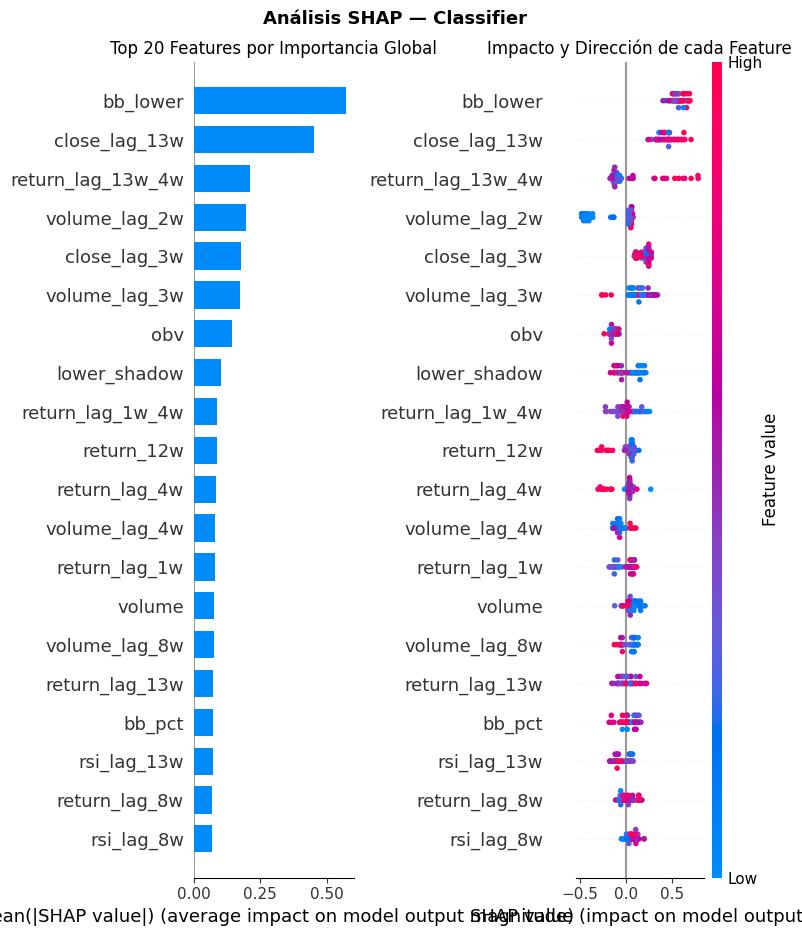


🏆 Top 10 features más predictivos (classifier):
   0.5731  bb_lower
   0.4525  close_lag_13w
   0.2097  return_lag_13w_4w
   0.1962  volume_lag_2w
   0.1787  close_lag_3w
   0.1718  volume_lag_3w
   0.1420  obv
   0.1041  lower_shadow
   0.0870  return_lag_1w_4w
   0.0859  return_12w
🔍 Calculando valores SHAP para regressor...


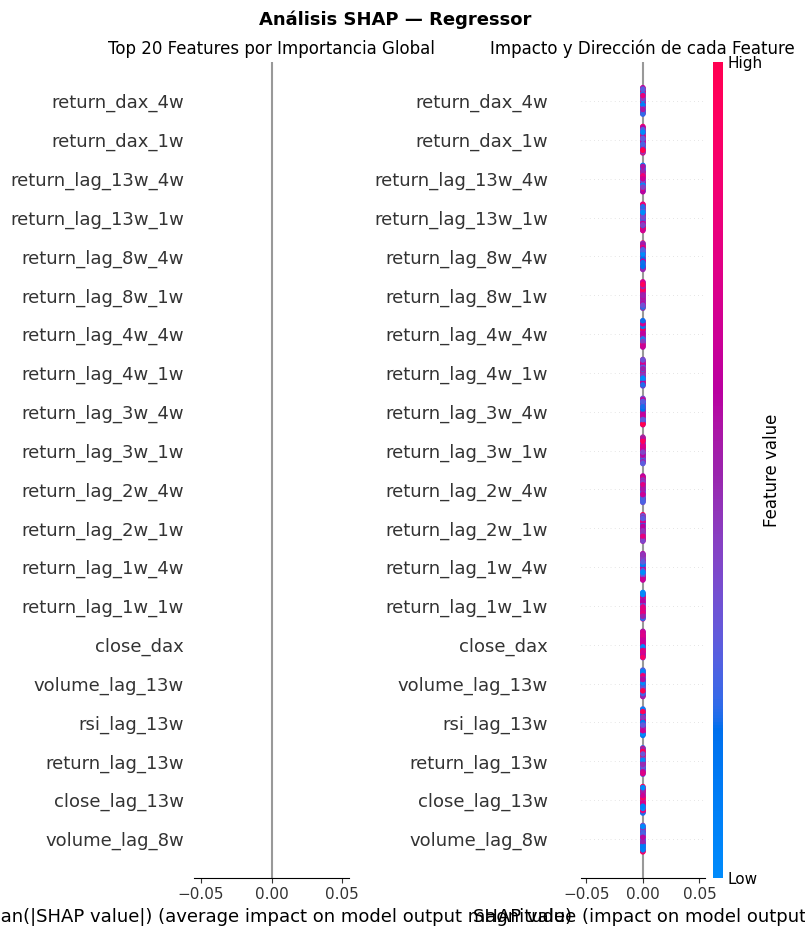


🏆 Top 10 features más predictivos (regressor):
   0.0000  open
   0.0000  high
   0.0000  low
   0.0000  close
   0.0000  volume
   0.0000  return_1w
   0.0000  return_2w
   0.0000  return_4w
   0.0000  return_12w
   0.0000  log_return


In [9]:
# Celda 6 — SHAP: qué features mueven realmente las predicciones

def plot_shap_analysis(model, X_test, feature_cols, model_type="classifier"):
    """
    Genera análisis SHAP para entender qué variables importan más.
    """
    print(f"🔍 Calculando valores SHAP para {model_type}...")
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # Para clasificación, shap_values puede ser lista [clase0, clase1]
    if isinstance(shap_values, list):
        shap_vals = shap_values[1]  # Clase positiva (alcista)
    else:
        shap_vals = shap_values

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f"Análisis SHAP — {model_type.capitalize()}", fontsize=13, fontweight="bold")

    plt.sca(axes[0])
    shap.summary_plot(shap_vals, X_test, plot_type="bar",
                      max_display=20, show=False)
    axes[0].set_title("Top 20 Features por Importancia Global")

    plt.sca(axes[1])
    shap.summary_plot(shap_vals, X_test,
                      max_display=20, show=False)
    axes[1].set_title("Impacto y Dirección de cada Feature")

    plt.tight_layout()
    plt.savefig(f"/content/data/shap_{model_type}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Top 10 features más importantes
    importance = np.abs(shap_vals).mean(axis=0)
    top_features = pd.Series(importance, index=X_test.columns)\
                     .sort_values(ascending=False).head(10)

    print(f"\n🏆 Top 10 features más predictivos ({model_type}):")
    for feat, val in top_features.items():
        print(f"   {val:.4f}  {feat}")

    return top_features


top_class_features = plot_shap_analysis(
    results["classifier"], X_test, feature_cols, "classifier"
)
top_reg_features = plot_shap_analysis(
    results["regressor"], X_test, feature_cols, "regressor"
)

— Celda 7 — Guardar modelos y resultados

In [10]:
# Celda 7 — Guardado corregido usando API nativa de XGBoost

def save_models_and_results(results, best_params_class, best_params_reg,
                             feature_cols, X_test, config):

    model_dir  = config["MODEL_DIR"]
    drive_dir  = config["DRIVE_DIR"]
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(os.path.join(drive_dir, "models"), exist_ok=True)

    # ── GUARDAR MODELOS con API nativa XGBoost ────────────────────────────
    clf_path = os.path.join(model_dir, "xgb_classifier.json")
    reg_path = os.path.join(model_dir, "xgb_regressor.json")

    results["classifier"].get_booster().save_model(clf_path)
    results["regressor"].get_booster().save_model(reg_path)
    print(f"💾 Modelos guardados en {model_dir}")

    # ── GUARDAR LISTA DE FEATURES (crítico para Fase 4) ───────────────────
    features_path = os.path.join(model_dir, "feature_cols.json")
    with open(features_path, "w") as f:
        json.dump(feature_cols, f)

    # ── GUARDAR PARÁMETROS Y MÉTRICAS ─────────────────────────────────────
    metrics = {
        "classifier": {
            "accuracy": round(float(results["acc"]), 4),
            "roc_auc":  round(float(results["auc"]), 4),
        },
        "regressor": {
            "mae":  round(float(results["mae"]), 4),
            "rmse": round(float(results["rmse"]), 4),
            "r2":   round(float(results["r2"]),  4),
        },
        "best_params_classifier": best_params_class,
        "best_params_regressor":  best_params_reg,
        "trained_at":  datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "n_features":  len(feature_cols),
        "train_size":  int(len(X_train)),
        "test_size":   int(len(X_test)),
    }
    metrics_path = os.path.join(model_dir, "model_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    # ── BACKUP EN GOOGLE DRIVE ────────────────────────────────────────────
    for filename in ["xgb_classifier.json", "xgb_regressor.json",
                     "feature_cols.json", "model_metrics.json"]:
        src  = os.path.join(model_dir, filename)
        dest = os.path.join(drive_dir, "models", filename)
        shutil.copy2(src, dest)
        print(f"☁️  Drive: {filename}")

    print("\n✅ Todo guardado correctamente")
    print(f"\n📊 Resumen de rendimiento:")
    print(f"   Clasificador — Accuracy: {results['acc']*100:.1f}% | AUC: {results['auc']:.3f}")
    print(f"   Regresor     — MAE: {results['mae']*100:.2f}% | R²: {results['r2']:.3f}")


save_models_and_results(
    results, best_params_class, best_params_reg,
    feature_cols, X_test, CONFIG
)

💾 Modelos guardados en /content/data/models
☁️  Drive: xgb_classifier.json
☁️  Drive: xgb_regressor.json
☁️  Drive: feature_cols.json
☁️  Drive: model_metrics.json

✅ Todo guardado correctamente

📊 Resumen de rendimiento:
   Clasificador — Accuracy: 55.8% | AUC: 0.502
   Regresor     — MAE: 1.54% | R²: -0.001
